In [1]:
#imports
import sklearn
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from collections import Counter

In [2]:
#files (I'm really only using the first one)
tfrecord = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_train_01.tfrecord"
tfrecord_test_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_test_00.tfrecord"
tfrecord_eval_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_eval_00.tfrecord"

In [3]:
feature_length = 4096  # all features have this length

feature_description = {
    'tmmx': tf.io.FixedLenFeature([feature_length], tf.float32),
    'FireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'th': tf.io.FixedLenFeature([feature_length], tf.float32),
    'erc': tf.io.FixedLenFeature([feature_length], tf.float32),
    'vs': tf.io.FixedLenFeature([feature_length], tf.float32),
    'elevation': tf.io.FixedLenFeature([feature_length], tf.float32),
    'tmmn': tf.io.FixedLenFeature([feature_length], tf.float32),
    'NDVI': tf.io.FixedLenFeature([feature_length], tf.float32),
    'sph': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pdsi': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pr': tf.io.FixedLenFeature([feature_length], tf.float32),
    'population': tf.io.FixedLenFeature([feature_length], tf.float32),
}

def _parse_function(proto):
    return tf.io.parse_single_example(proto, feature_description)

dataset = tf.data.TFRecordDataset(tfrecord)
parsed_dataset = dataset.map(_parse_function)

# Define the list of feature names and the label name
features_to_extract = ['tmmx', 'PrevFireMask', 'th', 'erc', 'vs', 'elevation',
                       'tmmn', 'NDVI', 'sph', 'pdsi', 'pr', 'population']
label_to_extract = 'FireMask'

In [6]:
all_features_data = [[],[],[],[],[],[],[],[],[],[],[],[]]
all_labels_data = []

for parsed_record in parsed_dataset:
    #the mean thing is kinda usless, but i don't feel like removing it rn
    if parsed_record['FireMask'].numpy().mean() >= 0:
        for i in range(len(features_to_extract)):
            all_features_data[i].append(
                parsed_record[features_to_extract[i]].numpy().reshape(64, 64)
            )
        all_labels_data.append(parsed_record[label_to_extract].numpy().reshape(64, 64))

all_features_data = np.array(all_features_data)       # (12, 850, 64, 64)
X_transposed = all_features_data.transpose(1, 2, 3, 0)  # (850, 64, 64, 12)
y_grid = np.array(all_labels_data)                    # (850, 64, 64)

n_records = X_transposed.shape[0]
X_neighbors = []
y_neighbors = []

for rec in range(n_records):
    # Exclude 1-pixel border: iterate rows 1..62, cols 1..62
    for r in range(1, 63):
        for c in range(1, 63):
            label = y_grid[rec, r, c]
            if label == -1:
                continue  # skip no-data pixels

            # Extract 3x3 neighborhood for all 12 features, then flatten
            # Shape: (3, 3, 12) -> (108,)
            neighborhood = X_transposed[rec, r-1:r+2, c-1:c+2, :]
            X_neighbors.append(neighborhood.flatten())
            y_neighbors.append(label)

X = np.array(X_neighbors)  # shape: (n_valid_pixels, 108)
y = np.array(y_neighbors)  # shape: (n_valid_pixels,)

assert set(np.unique(y)).issubset({0, 1}), "Found unexpected labels!"
print(f"Shape of features (X): {X.shape}")  # e.g. (n, 108)
print(f"Shape of labels (y): {y.shape}")
print(f"Label distribution: {np.bincount(y.astype(int))}")

Shape of features (X): (3265643, 108)
Shape of labels (y): (3265643,)
Label distribution: [3220517   45126]


In [7]:
# Full dataset
#Splits the data into training and testing sets
# Assuming X contains features and y contains target variable (labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2612514, 108)
X_test shape: (653129, 108)
y_train shape: (2612514,)
y_test shape: (653129,)


In [8]:
#actual model
lr_model = LogisticRegression(random_state=42)
#lr_model = MultiOutputClassifier(lr_estimator)
lr_model.fit(X_train, y_train)
# Make predictions on the test set
predictions = lr_model.predict(X_test)

print('success')

success


/Users/altheawu/Downloads/UMBC/Models/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Get fire probabilities
y_proba = lr_model.predict_proba(X_test)[:, 1]

# Compute precision-recall curve
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

# Plot precision and recall vs threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, prec[:-1], label='Precision', color='blue')
plt.plot(thresholds, rec[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find best threshold by maximizing F1
f1_scores = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
best_threshold_f1 = thresholds[np.argmax(f1_scores)]

# Find most balanced threshold (where precision and recall are closest)
best_threshold_balanced = thresholds[np.argmin(np.abs(prec[:-1] - rec[:-1]))]

print(f"Best F1 threshold:       {best_threshold_f1:.3f}")
print(f"Most balanced threshold: {best_threshold_balanced:.3f}")

# Apply threshold (change to best_threshold_balanced if preferred)
best_threshold = best_threshold_f1
y_pred = (y_proba >= best_threshold).astype(int)

# Evaluate
print(f"\nResults at threshold = {best_threshold:.3f}:")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, predictions))
overall_precision = precision_score(y_test, y_pred, average = 'macro')
overall_recall = recall_score(y_test, y_pred, average = 'macro')
print(f"Overall Precision: {overall_precision}")
print(f"Overall Recall: {overall_recall}")

In [ ]:
def predict_with_threshold(model, X, threshold):
    y_proba = model.predict_proba(X)[:, 1]
    return (y_proba >= threshold).astype(int)
threshold = 0.15

# Use it anywhere you need predictions
y_pred = predict_with_threshold(lr_model, X_test, threshold)

predictions = predict_with_threshold(lr_model, X_test, threshold)

Visualization & analysis

In [9]:
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

overall_accuracy = accuracy_score(y_test, predictions)

overall_precision = precision_score(y_test, predictions, average = 'macro')
overall_recall = recall_score(y_test, predictions, average = 'macro')
overall_f1 = f1_score(y_test, predictions, average = 'macro')

print(f"Accuracy: {overall_accuracy}")

print(f"Overall Precision: {overall_precision}")
print(f"Overall Recall: {overall_recall}")
print(f"Overall F1 Score: {overall_f1}")

print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.98520200450447
Overall Precision: 0.4930932431334744
Overall Recall: 0.49949387998435063
Overall F1 Score: 0.4962729245029088

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    644116
         1.0       0.00      0.00      0.00      9013

    accuracy                           0.99    653129
   macro avg       0.49      0.50      0.50    653129
weighted avg       0.97      0.99      0.98    653129



In [10]:
#Single record prediction visualization

dataset = tf.data.TFRecordDataset(tfrecord)

num_records_to_skip = 2

second_parsed_dataset = dataset.map(_parse_function).skip(num_records_to_skip).take(1)

features_data = [[],[],[],[],[],[],[],[],[],[],[],[]]
labels_data = []

for parsed_record in second_parsed_dataset:
  #if parsed_record['FireMask'].numpy().mean() >= 0:
    for i in range(len(features_to_extract)):
        features_data[i].append(parsed_record[features_to_extract[i]].numpy())
    labels_data.append(parsed_record[label_to_extract].numpy())

features_data = np.array(features_data)

print(f"Shape of features_data: {features_data.shape}") 

# Shape: (n_records, 64, 64, 12)
X_transposed_single = features_data.transpose(1, 2, 0).reshape(-1, 64, 64, 12)
# Shape: (n_records, 64, 64)
y_grid_single = np.array(labels_data).reshape(-1, 64, 64)

n_records = X_transposed_single.shape[0]
X_neighbors_single = []
y_neighbors_single = []

for rec in range(n_records):
    # Exclude 1-pixel border: iterate rows 1..62, cols 1..62
    for r in range(1, 63):
        for c in range(1, 63):
            label = y_grid_single[rec, r, c]

            # Extract 3x3 neighborhood for all 12 features, then flatten
            # Shape: (3, 3, 12) -> (108,)
            neighborhood_single = X_transposed_single[rec, r-1:r+2, c-1:c+2, :]
            X_neighbors_single.append(neighborhood_single.flatten())
            y_neighbors_single.append(label)

X_single = np.array(X_neighbors_single)  # shape: (n_valid_pixels, 108)
y_single = np.array(y_neighbors_single)  # shape: (n_valid_pixels,)

#assert set(np.unique(y_single)).issubset({0, 1}), "Found unexpected labels!"
print(f"Shape of features (X): {X_single.shape}")  # e.g. (n, 108)
print(f"Shape of labels (y): {y_single.shape}")
#print(f"Label distribution: {np.bincount(y_single.astype(int))}")

Shape of features_data: (12, 1, 4096)
Shape of features (X): (3844, 108)
Shape of labels (y): (3844,)


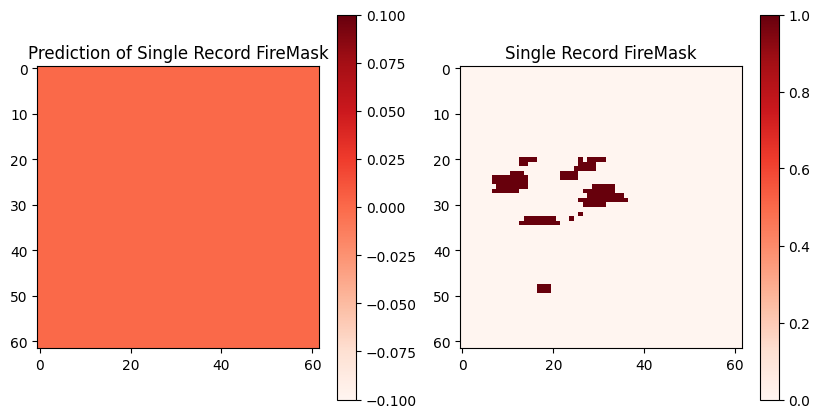

In [11]:
single_record_prediction = lr_model.predict(X_single)

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.title(f"Prediction of Single Record FireMask")
plt.imshow(single_record_prediction.reshape(62,62), cmap="Reds")
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f"Single Record FireMask")
plt.imshow(y_single.reshape(62,62), cmap="Reds")
plt.colorbar()

plt.show()